**Shapley $R^2$ decomposition/dominance analysis** (mathematical introduction): 

Quantifiable measure of the marginal contribution to total residual/variance ($R^2$) due to *each* variable compared to a baseline. 

Do a baseline fit, e.g. `(ne, Bt)`, then add a new variable e.g. `Ip` and compute the marginal reduction in total variance, 

$\Delta R^2_{I_p} = R^2(n_e,B_t,I_p) - R^2(n_e,B_t)$.

But notice that one could take `Ip` *before* `Bt`, (or other combinations, even `Ip` *before* `ne` *and/or* `Bt`) and get a different $\Delta R^2$. In this example, since `Ip` and `Bt` tend to be positively correlated, the first one to go into the fit contributes a larger apparent marginal reduction to uncertainty, even though the final fitted exponent will be the same.

The idea of dominance analysis is to average over the $p!$ different orderings for $p$ independent regressors. Take $x_1,...,x_p$ as the candidate regressors. A permutation $\sigma \in S_p$ fixes an ordering. In that ordering, the (fixed) regressor $x_j$ lands in the slot $\sigma^{-1}(j) \equiv k_j$.
The marginal contribution of $x_j$ in that ordering is 

$\overline{\Delta R^2}_j(\sigma) = R^2(x_{\sigma(1)}, ..., x_{\sigma(k_j-1)}, x_j) - R^2(x_{\sigma(1)}, ..., x_{\sigma(k_j-1)}).$

Let the following denote the squared residual of the $m \leq p$ variable fit under the permutation $\sigma,$

$R^2_\sigma (m) \equiv R^2(x_{\sigma(1)}, ... , x_{\sigma(m)})$.

Thus, the average marginal contribution of the regressor $x_j$ over all permutations is

$\overline{\Delta R^2}_j = \frac{1}{p!} \sum_{\sigma \in S_p}\lbrack R^2_{\sigma}(k_j) - R^2_\sigma (k_j - 1) \rbrack,$

where $k_j = \sigma^{-1}(j)$.

**Derivation of formula for OLS variance attribution**

$R^2_\sigma(m)$ (the residual of the $m \leq p$ fit) does *not* depend on the order of the $m$ regressors, only *which $m$* out of the total $p$ regressors in the full set.
Say we have $r$ regressors already, and we want to compute the change in residual due to adding $x_j$ at the slot $k_j = r + 1$. The multiplicity is 

$r! \times 1 \times (p-1-r)! = r!(p-1-r)!$,

i.e. there are r! way to permute the first r regressors, 1 way for $x_j$ fixed, and $(p-1-r)!$ ways for those that remain. Every one of these orderings yields the same summand $R^2(x_{i_1}, ... , x_{i_r}, x_j) - R^2(x_{i_1}, ... , x_{i_r})$, where $i_1 < i_2 < ... < i_r$ (all $i_a \neq j$) is an increasing index sequence of length r from the set $\{1, ..., p\}\setminus j$ of all indices (without j).

Each collection of such indices counts a *unique value* of the summand. So the final average is the sum over such collections, multiplied by the appropriate multiplicity, divided by the total number of permutations, and for every possible $0 \leq r < p$ (not including $r=p$, since $x_j$ is appended to the set of $r$ regressors). i.e.

$\overline{\Delta R^2_j} = \sum_{r=0}^{p-1} \frac{r!(p-1-r)!}{p!} \sum_{i_1 < ... < i_r \, ; \, i_a \neq j} \lbrack R^2(x_{i_1}, ... , x_{i_r}, x_j) - R^2(x_{i_1}, ... , x_{i_r}) \rbrack$.

This is the formula upon which the `shapeley_r2(*)` implementation is based. 










## Notebook Description

Analyses A–C use a **flat baseline (intercept only)**, e.g. `n_e`, `B_t`, and `S` compete on-par alongside every other candidate, to avoid bias towards the conventional scalings.

The three analyses are as follows:

- **A — pooled, both eras, three machines** (AUG/JET/C-Mod): `n_e`, `B_t`, `S`, `I_p`,
  `isotope_mass`, elongation, aspect ratio, heating scheme, wall material. In addition, we have a machine specific offset (multiplying factor) and machine specific exponents for `Ip`, `Bt` and `ne`.
- **B — tc26 only, three machines**: same as A, minus wall material (constant within one era).
- **C — 2008 only, three machines**: same as B minus `isotope_mass` (SELEC2007 is deuterium only).

In [149]:
import itertools
import math
from collections.abc import Iterable

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

from simdb.config.config import Config
from simdb.database import get_local_db
from simdb.query import QueryType

db = get_local_db(Config())
EMPTY_FLOAT = 9e40  # imas.EMPTY_FLOAT 
MACHINES = ["AUG", "JET", "CMOD"]
NEW_WALL = {2, 10}  # materials_identifier: W, Be
ICRH = {"IC", "NBIC"}  # coarse, cross-machine "uses ion-cyclotron heating" flag


def _guard(x: npt.ArrayLike) -> np.ndarray:
    """Replace empty float with NaN"""
    a = np.asarray(x, dtype=float)
    return np.where(np.abs(a) >= EMPTY_FLOAT, np.nan, a)


def _path(md: dict, *keys: str, n: int) -> np.ndarray:
    node = md
    for k in keys:
        if not isinstance(node, dict) or k not in node:
            return np.full(n, np.nan)
        node = node[k]
    return _guard(node)


def _temp(md: dict, *names: str, n: int) -> np.ndarray:
    """First matching temporary-IDS quantity: dbvariable.<name> or standard_name.<name>."""
    for bucket in ("dbvariable", "standard_name"):
        for name in names:
            v = md.get(bucket, {}).get(name)
            if v is not None:
                return _guard(v)
    return np.full(n, np.nan)


def load_pooled(dataset: str, selec_key: str, machines: list[str]) -> np.ndarray:
    """SELEC-flagged slices for a set of machines, with every variable this notebook tests."""
    rows = []
    for machine in machines:
        sims = db.query_meta([
            ("dataset", dataset, QueryType.EQ), ("machine", machine, QueryType.EQ),
            (f"dbvariable.{selec_key}", "1", QueryType.EQ),
        ])
        for sim in sims:
            md = sim.meta_dict()
            selec = _temp(md, selec_key, n=0)
            n = len(selec)
            if n == 0:
                continue
            bt = _path(md, "global_quantities", "b0", "value", n=n)
            ne = _path(md, "line_average", "n_e", "value", n=n)
            plth = _path(md, "global_quantities", "power_loss", "value", n=n)
            pl = _temp(md, "PL", n=n)
            splasma = _temp(md, "SPLASMA", "area_of_separatrix", n=n)
            meff = _path(md, "volume_average", "meff_hydrogenic", "value", n=n)
            kappa = _path(md, "boundary", "elongation", "value", n=n)
            rgeo = _path(md, "boundary", "geometric_axis_r", "value", n=n)
            amin = _path(md, "boundary", "minor_radius", "value", n=n)
            ip = _path(md, "global_quantities", "ip", "value", n=n)

            n_slices = min(len(a) for a in
                            (selec, bt, ne, plth, pl, splasma, meff, kappa, rgeo, amin, ip))
            if n_slices == 0:
                continue
            sel_mask = selec[:n_slices] == 1
            if not sel_mask.any():
                continue
            pl_eff = np.where(np.isnan(plth[:n_slices]), pl[:n_slices], plth[:n_slices])
            wall_idx = md.get("wall", {}).get("material", {}).get("index", np.nan)
            auxheat_raw = md.get("dbvariable", {}).get("AUXHEAT")
            divcon_raw = md.get("dbvariable", {}).get("DIVCON")  # tc26 JET only
            for i in np.nonzero(sel_mask)[0]:
                ah = auxheat_raw[i] if auxheat_raw is not None and i < len(auxheat_raw) else None
                dc = divcon_raw[i] if divcon_raw is not None and i < len(divcon_raw) else None
                rows.append((machine, bt[i], ne[i], pl_eff[i], splasma[i], meff[i], kappa[i],
                             rgeo[i], amin[i], ip[i], wall_idx, ah, dc))

    dtype = [("machine", "U4"), ("bt", float), ("ne", float), ("pl", float), ("s", float),
             ("meff", float), ("kappa", float), ("rgeo", float), ("amin", float),
             ("ip", float), ("wall_idx", float), ("auxheat", object), ("divcon", object)]
    return np.array(rows, dtype=dtype)


def valid_mask(d: np.ndarray, require_deuterium: bool = True) -> np.ndarray:
    """All core variables finite/positive; shared by every analysis below.

    require_deuterium restricts to meff ~= 2.0, needed wherever isotope_mass isn't itself a
    free regressor. Only relevant for tc26 data.
    """
    mask = (
        np.isfinite(d["bt"]) & np.isfinite(d["ne"]) & np.isfinite(d["pl"]) & np.isfinite(d["s"])
        & np.isfinite(d["kappa"]) & np.isfinite(d["rgeo"]) & np.isfinite(d["amin"]) & np.isfinite(d["ip"])
        & np.isfinite(d["meff"]) & (d["meff"] > 0)
        & (d["pl"] > 0) & (d["ne"] > 0) & (d["s"] > 0) & (d["kappa"] > 0)
        & (d["rgeo"] > 0) & (d["amin"] > 0) & (d["ip"] != 0)
        & (d["auxheat"] != None)
    )
    if require_deuterium:
        mask &= np.isclose(d["meff"], 2.0, atol=0.05)
    return mask


def _sum_to_zero_codes(machine: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Unweighted sum-to-zero (effect) contrast codes for {AUG, JET, CMOD}: AUG=(1,0), JET=(0,1),
    CMOD=(-1,-1). Deviations for all three machines sum to zero by construction.
    """
    code_aug = np.where(machine == "AUG", 1.0, np.where(machine == "CMOD", -1.0, 0.0))
    code_jet = np.where(machine == "JET", 1.0, np.where(machine == "CMOD", -1.0, 0.0))
    return code_aug, code_jet


# **named_vars takes declared variables into a dictionary, i.e. machine_slope_blocks(d["machine"],
# ip=log_ip, bt=log_bt, ne=log_ne) -> {"ip": log_ip, "bt": log_bt, "ne": log_ne}
def machine_slope_blocks(machine: np.ndarray, **named_vars: np.ndarray) -> dict[str, np.ndarray]:
    """Machine-specific variable interaction blocks for capturing device-specific slope heterogeneity, 
    on top of machine_offset's flat per-machine level shift. Uses the same unweighted sum-to-zero coding 
    as machine_offset (see _sum_to_zero_codes) rather than pegging deviations to one reference
    machine."""
    code_aug, code_jet = _sum_to_zero_codes(machine)
    return {
        f"machine_{name}": np.column_stack([code_aug * v, code_jet * v])
        for name, v in named_vars.items()
    }


def named_blocks(
    d: np.ndarray, include_wall: bool, include_isotope: bool = False,
    include_machine_slopes: bool = False,
) -> dict[str, np.ndarray]:
    """Flat-baseline candidate blocks for Analyses A/B/C."""
    log_ne = np.log(d["ne"] / 1e20)
    log_bt = np.log(np.abs(d["bt"]))
    log_ip = np.log(np.abs(d["ip"]) / 1e6)
    code_aug, code_jet = _sum_to_zero_codes(d["machine"])
    blocks = {
        "ne": log_ne.reshape(-1, 1),
        "Bt": log_bt.reshape(-1, 1),
        "S": np.log(d["s"]).reshape(-1, 1),
        "elongation": np.log(d["kappa"]).reshape(-1, 1),
        "aspect_ratio": np.log(d["amin"] / d["rgeo"]).reshape(-1, 1),
        "Ip": log_ip.reshape(-1, 1),
        "heating_scheme": np.isin(d["auxheat"], list(ICRH)).astype(float).reshape(-1, 1),
        "machine_offset": np.column_stack([code_aug, code_jet]),
    }
    if include_wall:
        blocks["wall_material"] = np.isin(d["wall_idx"], list(NEW_WALL)).astype(float).reshape(-1, 1)
    if include_isotope:
        blocks["isotope_mass"] = np.log(d["meff"]).reshape(-1, 1)
    if include_machine_slopes:
        blocks.update(machine_slope_blocks(d["machine"], ip=log_ip, bt=log_bt, ne=log_ne))
    return blocks


def zscore(x: np.ndarray) -> np.ndarray:
    """z score of array"""
    return (x - x.mean()) / x.std()


component_colors = {
    "baseline": "#999999", "wall_material": "tab:orange", "ne": "tab:pink", "Bt": "tab:brown",
    "S": "gold", "elongation": "tab:green", "aspect_ratio": "tab:olive",
    "Ip": "tab:cyan", "heating_scheme": "tab:blue", "machine_offset": "tab:purple",
    "machine_ip": "tab:cyan", "machine_bt": "tab:brown", "machine_ne": "tab:pink",
    "divertor_config": "tab:red", "isotope_mass": "indigo",
    "Bt_ne_interaction": "darkslategray", "Bt_saturation": "firebrick", "ne_saturation": "peru",
    "unexplained": "#dddddd",
}

In [150]:
def shapley_r2(y: np.ndarray, base_cols: np.ndarray, blocks: dict[str, np.ndarray]) -> dict[str, float]:
    """Shapley/LMG decomposition of R^2 among candidate predictor blocks, on top of an
    always-included baseline.

    y: response (1D). base_cols: baseline design matrix, shape: (n_samples, n_base_cols), included in
    every model. blocks: {name: value.shape=(n_samples, n_block_cols)} candidate predictor groups.

    Returns {name: attributed R^2 share}, plus 'baseline' (R^2 with no blocks) and
    'unexplained' (1 - R^2 with all blocks). All values sum to exactly 1.
    """
    names = list(blocks.keys())
    K = len(names)

    def r2_for(subset_names):
        X = np.column_stack([base_cols] + [blocks[n] for n in subset_names])
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ coef
        return 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    r2_cache = {
        frozenset(combo): r2_for(combo)
        for r in range(K + 1) for combo in itertools.combinations(names, r)
    }

    shapley = {}
    for g in names:
        others = [n for n in names if n != g]
        total = 0.0
        for r in range(len(others) + 1):
            weight = math.factorial(r) * math.factorial(K - r - 1) / math.factorial(K)
            for combo in itertools.combinations(others, r):
                s = frozenset(combo)
                total += weight * (r2_cache[s | {g}] - r2_cache[s])
        shapley[g] = total

    return {"baseline": r2_for([]), **shapley, "unexplained": 1 - r2_for(names)}

## Analysis A: pooled, both eras, three machines

Flat baseline (intercept only). The deuterium filter is relaxed here too, with `isotope_mass` competing as its own block, even though 2008's contribution to that block is a hard constant (`meff = 2.0` for every 2008 pulse). `heating_scheme` is a coarse, cross-machine flag
(ion-cyclotron heating or not).

In [151]:
rowsA = [load_pooled(dataset, selec_key, MACHINES)
         for dataset, selec_key in [("2008", "SELEC2007"), ("tc26", "SELEC2024")]]
dA = np.concatenate(rowsA)
dA = dA[valid_mask(dA, require_deuterium=False)]
print(f"N = {len(dA)}")

yA = np.log(dA["pl"] / 1e6)
baseA = np.ones(len(dA)).reshape(-1, 1)
resultA = shapley_r2(yA, baseA, named_blocks(dA, include_wall=True, include_isotope=True, include_machine_slopes=True))
resultA

N = 1327


{'baseline': np.float64(1.1102230246251565e-16),
 'ne': np.float64(0.055162611913479855),
 'Bt': np.float64(0.023923694449333736),
 'S': np.float64(0.06466924964879915),
 'elongation': np.float64(0.0036285030861391344),
 'aspect_ratio': np.float64(0.02487085984315502),
 'Ip': np.float64(0.1347057879359553),
 'heating_scheme': np.float64(0.006273375730772651),
 'machine_offset': np.float64(0.11424963418408873),
 'wall_material': np.float64(0.009158182651188427),
 'isotope_mass': np.float64(0.06333837744514152),
 'machine_ip': np.float64(0.0976294793228593),
 'machine_bt': np.float64(0.12643475549063818),
 'machine_ne': np.float64(0.08827143301556802),
 'unexplained': np.float64(0.18768405528288123)}

## Analysis B: tc26 only, three machines

Same candidate set as A, minus wall material (constant within a single era), plus `isotope_mass`. No deuterium filter. 

In [152]:
dB = load_pooled("tc26", "SELEC2024", MACHINES)
dB = dB[valid_mask(dB, require_deuterium=False)]
print(f"N = {len(dB)}")

yB = np.log(dB["pl"] / 1e6)
baseB = np.ones(len(dB)).reshape(-1, 1)
resultB = shapley_r2(yB, baseB, named_blocks(dB, include_wall=False, include_isotope=True, include_machine_slopes=True))
resultB

N = 475


{'baseline': np.float64(0.0),
 'ne': np.float64(0.04181319832389169),
 'Bt': np.float64(0.010298937695406024),
 'S': np.float64(0.06614280934778466),
 'elongation': np.float64(0.015698050455983138),
 'aspect_ratio': np.float64(0.02030928056622548),
 'Ip': np.float64(0.1517350459806435),
 'heating_scheme': np.float64(0.012868538140572372),
 'machine_offset': np.float64(0.12926588514427323),
 'isotope_mass': np.float64(0.1315285451895326),
 'machine_ip': np.float64(0.10393196486610093),
 'machine_bt': np.float64(0.12322449970620072),
 'machine_ne': np.float64(0.11747073956736732),
 'unexplained': np.float64(0.0757125050160179)}

## Analysis C: 2008 only, three machines

Same set as B, on the older carbon/carbon-beryllium-wall era.

In [153]:
dC = load_pooled("2008", "SELEC2007", MACHINES)
dC = dC[valid_mask(dC)]
print(f"N = {len(dC)}")

yC = np.log(dC["pl"] / 1e6)
baseC = np.ones(len(dC)).reshape(-1, 1)
resultC = shapley_r2(yC, baseC, named_blocks(dC, include_wall=False, include_machine_slopes=True))
resultC

N = 852


{'baseline': np.float64(0.0),
 'ne': np.float64(0.06510893448615204),
 'Bt': np.float64(0.05426912032545574),
 'S': np.float64(0.06759327574938565),
 'elongation': np.float64(0.007407358933830174),
 'aspect_ratio': np.float64(0.026132961079420723),
 'Ip': np.float64(0.12677599254187746),
 'heating_scheme': np.float64(0.003665778860987177),
 'machine_offset': np.float64(0.10602145728716082),
 'machine_ip': np.float64(0.10444665589984496),
 'machine_bt': np.float64(0.12950505558998204),
 'machine_ne': np.float64(0.06839211679576614),
 'unexplained': np.float64(0.24068129245013736)}

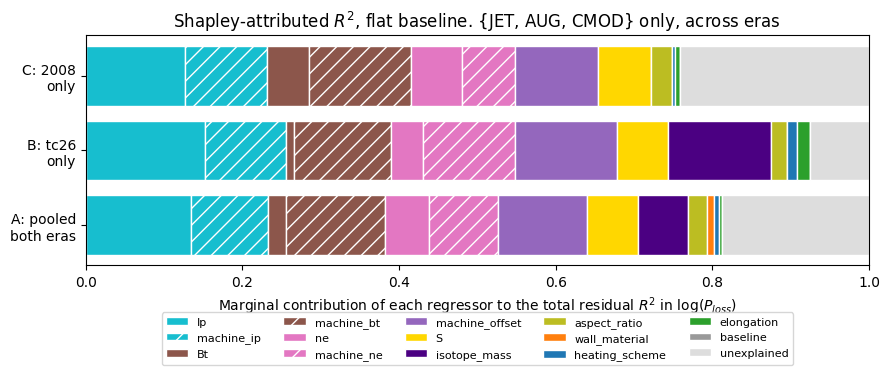

In [154]:
analyses = {"A: pooled\nboth eras": resultA, "B: tc26\nonly": resultB, "C: 2008\nonly": resultC}

# Order every bar by Analysis A's sizes (largest first), unexplained pinned last, so A/B/C stay
# visually aligned. Blocks A doesn't have (e.g. isotope_mass, B-only) sort as if 0 in A, landing 
# just before unexplained. machine_ip/machine_bt/machine_ne are placed immediately after their 
# parent variable (Ip/Bt/ne).
pair_map = {"Ip": "machine_ip", "Bt": "machine_bt", "ne": "machine_ne"}
machine_slope_comps = set(pair_map.values())
all_components = set(resultA) | set(resultB) | set(resultC)
primary = [k for k in all_components if k not in machine_slope_comps and k != "unexplained"]


def pair_total(k):
    total = resultA.get(k, 0.0)
    pair = pair_map.get(k)
    if pair in all_components:
        total += resultA.get(pair, 0.0)
    return total

component_order_abc = []
for k in sorted(primary, key=pair_total, reverse=True):
    component_order_abc.append(k)
    if pair_map.get(k) in all_components:
        component_order_abc.append(pair_map[k])
component_order_abc.append("unexplained")

fig, ax = plt.subplots(figsize=(9, 4))
labels = list(analyses.keys())
bottoms = np.zeros(len(labels))
for comp in component_order_abc:
    vals = np.array([analyses[k].get(comp, 0.0) for k in labels])
    hatch = "//" if comp in machine_slope_comps else None
    ax.barh(labels, vals, left=bottoms, color=component_colors[comp], label=comp, edgecolor="white", hatch=hatch)
    bottoms += vals

ax.set_xlabel(r"Marginal contribution of each regressor to the total residual $R^2$ in $\log(P_{loss})$")
ax.set_xlim(0, 1)
ax.set_title(r"Shapley-attributed $R^2$, flat baseline. {JET, AUG, CMOD} only, across eras")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=5, fontsize=8)
fig.tight_layout()

| | `n_e` total (+`machine_ne`) | `B_t` total (+`machine_bt`) | `S` | `I_p` total (+`machine_ip`) | isotope mass | elongation | aspect ratio | heating scheme | `machine_offset` | wall material | unexplained |
|---|---|---|---|---|---|---|---|---|---|---|---|
| A: pooled, both eras | 14.3% | 15.0% | 6.5% | 23.2% | 6.3% | 0.4% | 2.5% | 0.6% | 11.4% | 0.9% | 18.8% |
| B: tc26 only | 15.9% | 13.4% | 6.6% | 25.6% | 13.2% | 1.6% | 2.0% | 1.3% | 12.9% | — | 7.6% |
| C: 2008 only | 13.4% | 18.4% | 6.8% | 23.1% | — | 0.7% | 2.6% | 0.4% | 10.6% | — | 24.1% |

**`I_p`'s common component is the majority of its total.**
Common `I_p` is 13.5%/15.2%/12.7% in A/B/C vs. `machine_ip`'s 9.8%/10.4%/10.4% — roughly 55–60%
common in every analysis. 

**`B_t` is solidly device-dominated.** Common `B_t` is small in all three (2.4%/1.0%/5.4%)
against `machine_bt`'s 12.6%/12.3%/13.0%, a 2.4–12× gap depending on the analysis.

**Total device-attributable variance** (`machine_offset` + `machine_ip` + `machine_bt` +
`machine_ne`) is 42.7% (A), 47.4% (B), 40.8% (C).
Device heterogeneity is concentrated in slopes rather than a flat per-device level, and especially concentrated in `B_t`.

## Power law vs. symbolic regression (Murari *et al.* 2013), like-for-like on 2008 only

Murari *et al.* 2013 used genetic-programming symbolic regression to search for the best
unconstrained model structure for `P_loss`, without the power-law assumption, and found a 
structure (paper: eq. 5) that is purely additive rather than multiplicative: linear terms in
`n_e`, `B_t`, `S`, `k` (elongation), plus a `B_t·n_e` interaction and two *saturation* terms
(`-B_t^2`, `-n_e^2`). Their AUG/JET fit uses all seven terms; their own CMOD-specific fit drops the
interaction and `B_t^2` term.

The following analysis is motivated to (roughly) test the robustness of variance attribution 
for the same set of regressors across *different model assumptions*, i.e. non-power laws. The comparison
keeps the dataset constant and varies only the model assumption (2008, CMOD+JET+AUG only, SELEC2007 pulses).

The one deliberate departure from the paper is that `log(P_loss)` stays as the response rather than raw 
`P_loss`, so that the two bars remian directly comparable. `n_e`, `B_t`, `S`, and `k` are standardized before 
building the interaction/saturation terms. Centering matters here, since the NPL model is not scale-invariant 
and changes how credit splits between the linear and nonlinear pieces.

In [155]:
ne_z = zscore(dC["ne"] / 1e20)
bt_z = zscore(np.abs(dC["bt"]))
s_z = zscore(dC["s"])
elongation_z = zscore(dC["kappa"])
log_ip_C = np.log(np.abs(dC["ip"]) / 1e6)
code_aug_C, code_jet_C = _sum_to_zero_codes(dC["machine"])

blocksC_npl = {
    "ne": ne_z.reshape(-1, 1),
    "Bt": bt_z.reshape(-1, 1),
    "S": s_z.reshape(-1, 1),
    "elongation": elongation_z.reshape(-1, 1),
    "Bt_ne_interaction": (bt_z * ne_z).reshape(-1, 1),
    "Bt_saturation": (bt_z**2).reshape(-1, 1),
    "ne_saturation": (ne_z**2).reshape(-1, 1),
    "aspect_ratio": np.log(dC["amin"] / dC["rgeo"]).reshape(-1, 1),
    "Ip": log_ip_C.reshape(-1, 1),
    "heating_scheme": np.isin(dC["auxheat"], list(ICRH)).astype(float).reshape(-1, 1),
    "machine_offset": np.column_stack([code_aug_C, code_jet_C]),
}
blocksC_npl.update(machine_slope_blocks(dC["machine"], ip=log_ip_C, bt=bt_z, ne=ne_z))
resultC_npl = shapley_r2(yC, baseC, blocksC_npl)
resultC_npl

{'baseline': np.float64(0.0),
 'ne': np.float64(0.04162913650643271),
 'Bt': np.float64(0.05227429997741),
 'S': np.float64(0.07961548019145868),
 'elongation': np.float64(0.009688455943024407),
 'Bt_ne_interaction': np.float64(0.014043690628019124),
 'Bt_saturation': np.float64(0.015874961807243577),
 'ne_saturation': np.float64(0.011052570940876121),
 'aspect_ratio': np.float64(0.034992865968729796),
 'Ip': np.float64(0.14216429286113155),
 'heating_scheme': np.float64(0.004968445604917978),
 'machine_offset': np.float64(0.12137551129129871),
 'machine_ip': np.float64(0.10984987318195318),
 'machine_bt': np.float64(0.05749871333195841),
 'machine_ne': np.float64(0.05681129706702612),
 'unexplained': np.float64(0.24816040469851974)}

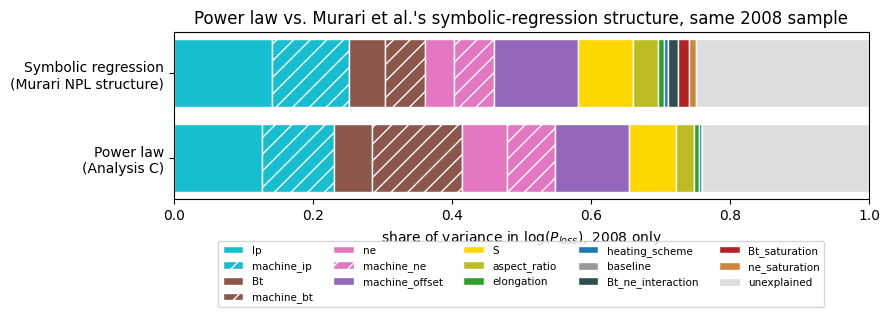

In [156]:
comparisonC_npl = {"Power law\n(Analysis C)": resultC, "Symbolic regression\n(Murari NPL structure)": resultC_npl}

# Same combined-pair-size ordering rule as the A/B/C plot above, using Analysis C (the power-law
# fit) as the reference for ranking so the two bars stay aligned.
pair_map = {"Ip": "machine_ip", "Bt": "machine_bt", "ne": "machine_ne"}
machine_slope_comps = set(pair_map.values())
all_components_npl = set(resultC) | set(resultC_npl)
primary_npl = [k for k in all_components_npl if k not in machine_slope_comps and k != "unexplained"]


def pair_total_npl(k):
    total = resultC.get(k, 0.0)
    pair = pair_map.get(k)
    if pair in all_components_npl:
        total += resultC.get(pair, 0.0)
    return total


component_order_npl = []
for k in sorted(primary_npl, key=pair_total_npl, reverse=True):
    component_order_npl.append(k)
    if pair_map.get(k) in all_components_npl:
        component_order_npl.append(pair_map[k])
component_order_npl.append("unexplained")

fig, ax = plt.subplots(figsize=(9, 3.5))
labels = list(comparisonC_npl.keys())
bottoms = np.zeros(len(labels))
for comp in component_order_npl:
    vals = np.array([comparisonC_npl[k].get(comp, 0.0) for k in labels])
    hatch = "//" if comp in machine_slope_comps else None
    ax.barh(labels, vals, left=bottoms, color=component_colors[comp], label=comp, edgecolor="white", hatch=hatch)
    bottoms += vals

ax.set_xlabel(r"share of variance in $\log(P_{loss})$, 2008 only")
ax.set_xlim(0, 1)
ax.set_title("Power law vs. Murari et al.'s symbolic-regression structure, same 2008 sample")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=5, fontsize=7.5)
fig.tight_layout()

## The power law beats the symbolic-regression structure (expected), and `I_p`'s split is stable across both, `B_t`'s isn't

| | total $R^2$ | `n_e` total | `B_t` total | `S` | `I_p` total | interaction | elongation | aspect ratio | heating scheme | `machine_offset` | unexplained |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Power law | 75.9% | 13.4% | 18.4% | 6.8% | 23.1% | — | 0.7% | 2.6% | 0.4% | 10.6% | 24.1% |
| Symbolic regression (NPL) | 75.2% | 10.9% | 12.6% | 8.0% | 25.2% | 1.4% | 1.0% | 3.5% | 0.5% | 12.1% | 24.8% |

Total $R^2$ of the power law beats the NPL, however this is expected since the {AUG,CMOD,JET} subset of 2008 database differs from the one used to derive the NPL model, and also since we used `log(P_loss)` instead of `P_loss`

**`I_p`'s common/device-specific split is still stable across both functional forms.** Its common component is 12.7% (power law) vs. 14.2% (NPL), and its device-specific component (`machine_ip`) is 10.4% vs. 11.0%.

** `B_t`'s split is not as stable, however the difference is still concentrated in the device-specific piece. ** Can be partly explained due to saturation and interaction terms with `n_e`.

`machine_offset` itself shifts modestly (10.6% vs. 12.1%) but stays in a similar range under both functional forms.